# Lab 09: Sparse Autoencoders & Mechanistic Interpretability
**Duration**: 120 min | **Prerequisites**: Lab 07 (Transformers), Lab 08 (Hugging Face)  
**GPU**: Free Colab T4 — Runtime → Change runtime type → T4 GPU

## 🎯 Learning Objectives
- Explain why neural networks exhibit **polysemanticity**
- Understand what a Sparse Autoencoder does, conceptually
- Extract and identify features from GPT-2 Small on philosophical text
- Test whether features are genuine concept encodings or **dataset artifacts**
- **Prove causation** — not just correlation — using activation steering and suppression ablation
- Understand what SAE-based interpretability can and cannot establish

## 📚 Pre-Lab Reading (30 min)
| Resource | What to focus on |
|----------|------------------|
| [Towards Monosemanticity — Cunningham et al., 2023](https://transformer-circuits.pub/2023/monosemantic-features/index.html) | Intro + all figures (~15 min) — skip the math |
| [3Blue1Brown — What is a Neural Network?](https://www.youtube.com/watch?v=aircAruvnKk) | Full video (~19 min) |

In [ ]:
!pip install -q sae-lens transformer-lens
print('✅ Installation complete!')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.9/309.9 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 26.3 MB/s eta 0:00:00
✅ Installation complete!


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os
from transformer_lens import HookedTransformer
from sae_lens import SAE

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cpu':
    print('⚠️  No GPU detected. Parts 3–6 will be slow. Go to Runtime → Change runtime type → T4 GPU.')
else:
    print('✅ GPU ready!')

Using device: cuda
✅ GPU ready!


## Part 1: Polysemanticity — Why Neurons Are Hard to Interpret (15 min)

### 📚 The Problem
A **polysemantic** neuron fires for many unrelated concepts. For example, neuron 2049 in GPT-2 activates for the word "banana", the color yellow, and curved shapes — and dozens of other unrelated things.

This makes it nearly impossible to understand what any single neuron "means."

### 📚 Why Does This Happen? — The Superposition Hypothesis
Networks have *fewer neurons* than there are real-world features to represent. To pack more information in, they store features in **superposition**: overlapping directions in activation space.

> "A model can represent more features than it has neurons, as long as the features are sparse." — Elhage et al., 2022

The toy model below demonstrates this. Five real-world features are packed into a 2D space.

Training toy model...
✅ Done. Reconstruction loss: 0.0058


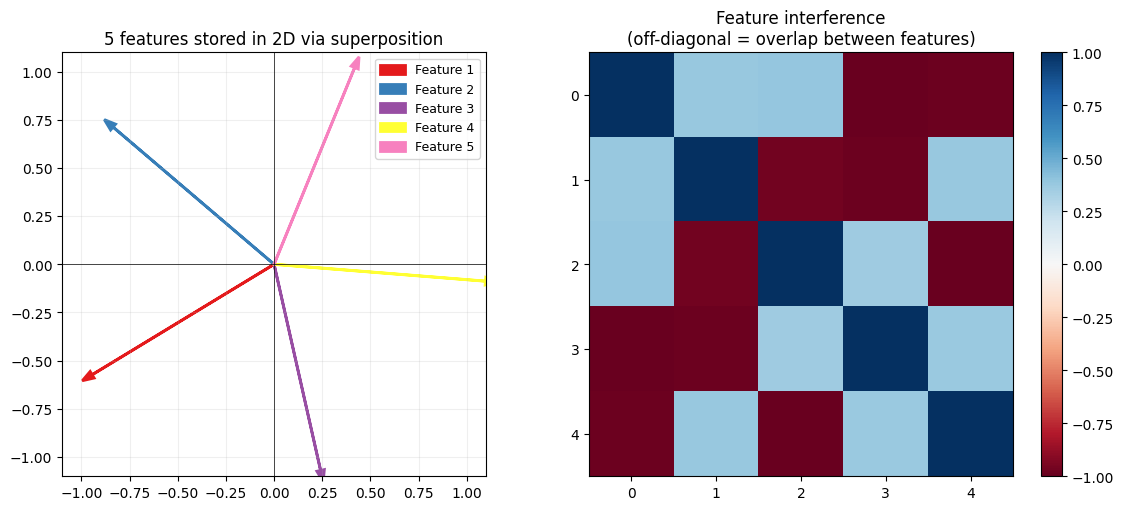

In [ ]:
# 🔍 DEMONSTRATION: Toy Model of Superposition

def create_sparse_data(n_features=5, n_hidden=2, batch=2000, sparsity=0.1):
    x    = torch.rand(batch, n_features)
    mask = torch.bernoulli(torch.full_like(x, sparsity))
    return x * mask

class ToyModel(nn.Module):
    def __init__(self, n_features=5, n_hidden=2):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_features) * 0.3)
        self.b = nn.Parameter(torch.zeros(n_features))
    def forward(self, x):
        h = x @ self.W.T
        return torch.relu(h @ self.W + self.b)

toy_model = ToyModel()
opt       = torch.optim.Adam(toy_model.parameters(), lr=0.01)
print('Training toy model...')
for step in range(3000):
    x    = create_sparse_data()
    loss = ((x - toy_model(x)) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print(f'✅ Done. Reconstruction loss: {loss.item():.4f}')

W      = toy_model.W.detach().numpy()
colors = plt.cm.Set1(np.linspace(0, 0.8, 5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(5):
    axes[0].arrow(0, 0, W[0, i], W[1, i], head_width=0.04,
                  color=colors[i], label=f'Feature {i+1}', linewidth=2)
axes[0].set_xlim(-1.1, 1.1); axes[0].set_ylim(-1.1, 1.1)
axes[0].set_aspect('equal')
axes[0].set_title('5 features stored in 2D via superposition')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

feat_vecs    = W.T
interference = feat_vecs @ feat_vecs.T
im = axes[1].imshow(interference, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Feature interference\n(off-diagonal = overlap between features)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

### 📖 Reading the Diagram

**Why can't we read off "Feature 3" from the neurons directly?**  
The 2D space (the neurons) combines all five features simultaneously. Each neuron's value is a weighted mixture of multiple feature contributions. There is no one-to-one mapping between a neuron and a concept — the mapping is many-to-many.

**A philosophical analogy**: this is the same structure as lexical ambiguity. The English word "right" doesn't isolate a single concept — it blends legal entitlement, moral correctness, and spatial direction. Context resolves the ambiguity. Neurons are ambiguous in the same way; context in the surrounding layers has to resolve what each neuron "means" at any given moment. The SAE's job is to find the unambiguous underlying concepts.

**What the SAE does**: It recovers the 5 original arrows from the tangled 2D space. In GPT-2 Small, it recovers 24,576 concept-directions from a 768-dimensional space. The next section explains how.

## Part 2: How Sparse Autoencoders Work — Conceptual Tour (10 min)

### Architecture

```
Input: activation vector  [768 numbers from GPT-2 layer 8]
            │
            ▼  Encoder: linear projection + ReLU
            │
    Feature activations  [24,576 numbers — most are ZERO]
            │
            ▼  Decoder: linear projection
            │
    Reconstructed input  [768 numbers, close to original]
```

### Three Key Ideas

**1. Expansion**: 768 dimensions → 24,576 features (32×). This gives enough room for every concept to occupy its own direction rather than sharing one.

**2. Sparsity penalty**: A penalty term during training pushes most of the 24,576 values to zero. For any given token, only ~20–50 features activate.

**3. Why sparsity leads to monosemanticity**: If you are allowed to use only 20 pencils out of 24,576, you choose precisely. Each pencil ends up encoding exactly the thing it is best at. Features that try to encode two unrelated concepts lose to specialized features in a competitive training regime.

*(In theory. Part 5 tests whether this holds in practice.)*

In [ ]:
# 📖 REFERENCE CODE — the SAE architecture; you do not need to modify this.

class SparseAutoencoder(nn.Module):
    '''
    Sparse Autoencoder: x → [linear + ReLU] → features → [linear] → x_recon
    Loss = reconstruction_error + lambda * L1_sparsity_penalty
    '''
    def __init__(self, d_model, d_sae, l1_coeff=0.001):
        super().__init__()
        self.W_enc = nn.Parameter(torch.randn(d_model, d_sae) / (d_model ** 0.5))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.randn(d_sae, d_model) / (d_sae ** 0.5))
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.l1_coeff = l1_coeff

    def encode(self, x):
        return torch.relu(x @ self.W_enc + self.b_enc)

    def decode(self, features):
        return features @ self.W_dec + self.b_dec

    def forward(self, x):
        features      = self.encode(x)
        x_recon       = self.decode(features)
        recon_loss    = ((x - x_recon) ** 2).mean()
        sparsity_loss = self.l1_coeff * features.abs().sum(-1).mean()
        return x_recon, features, recon_loss + sparsity_loss

demo_sae    = SparseAutoencoder(d_model=64, d_sae=256)
dummy       = torch.randn(4, 10, 64)
_, feats, _ = demo_sae(dummy)
print(f'Input:    {list(dummy.shape)}')
print(f'Features: {list(feats.shape)}  ← 256 features from 64 dims (4× expansion)')
print(f'Sparsity: {(feats == 0).float().mean().item():.0%} of features are zero')

Input:    [4, 10, 64]
Features: [4, 10, 256]  ← 256 features from 64 dims (4× expansion)
Sparsity: 50% of features are zero


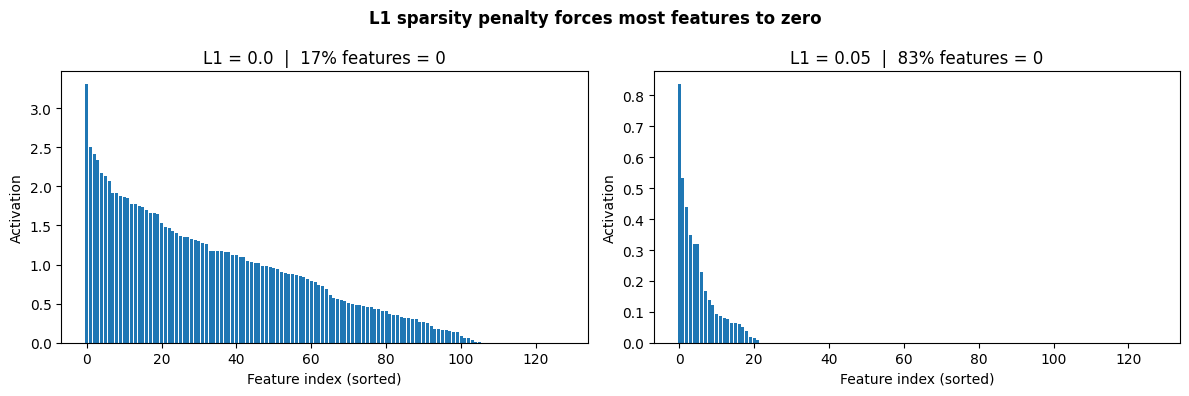

In [ ]:
# 🔍 DEMONSTRATION: Effect of the L1 sparsity penalty
# Left: no penalty → features spread out. Right: L1=0.05 → most features collapse to zero.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dummy_1d   = torch.randn(500, 64)

for ax, l1 in zip(axes, [0.0, 0.05]):
    sae_test = SparseAutoencoder(d_model=64, d_sae=128, l1_coeff=l1)
    opt_t    = torch.optim.Adam(sae_test.parameters(), lr=0.005)
    for _ in range(800):
        _, feats, loss_t = sae_test(dummy_1d)
        opt_t.zero_grad(); loss_t.backward(); opt_t.step()
    with torch.no_grad():
        _, feats, _ = sae_test(dummy_1d[:1])
    feat_vals = feats[0].detach().numpy()
    ax.bar(range(len(feat_vals)), sorted(feat_vals, reverse=True))
    ax.set_title(f'L1 = {l1}  |  {(feat_vals == 0).mean():.0%} features = 0')
    ax.set_xlabel('Feature index (sorted)'); ax.set_ylabel('Activation'); ax.set_ylim(0, None)

plt.suptitle('L1 sparsity penalty forces most features to zero', fontweight='bold')
plt.tight_layout(); plt.show()

## Part 3: Using a Pretrained SAE on GPT-2 (20 min)

### 📚 SAELens

[Joseph Bloom](https://github.com/jbloomAUS) trained SAEs on every layer of GPT-2 Small using [SAELens](https://jbloomaus.github.io/SAELens/). Each has **24,576 features** — a 32× expansion of the 768-dim residual stream. We use **layer 8**, which balances syntactic (early) and semantic (late) representations.

---

### 🔍 How to Look Up a Feature on Neuronpedia

The code in this section prints feature indices like `Feature  3842  avg=0.214`. To look up what feature 3842 encodes, run this in a code cell:

```python
print(neuronpedia_url(3842))
# → https://neuronpedia.org/gpt2-small/8-res-jb/3842
```

Copy that link into your browser. That is it — replace `3842` with whichever feature index you want to inspect.

**What you will see on the page — read in this order:**

**① Explanations** *(top of the page)*  
2–3 AI systems (GPT-3.5, GPT-4o-mini, Gemini) have each written a short label for what the feature encodes. **Start here.** If all three agree on a theme, the label is likely reliable. If they are vague — *"phrases related to actions"*, *"decision-making verbs"* — the feature probably encodes a grammatical pattern rather than a meaningful concept.

**② Positive logits** *(table on the right)*  
The tokens the model becomes more likely to produce when this feature fires strongly. Scan the top 5–10. If they cluster around a theme (e.g. all are moral/legal vocabulary), that theme is likely what the feature encodes.

**③ Negative logits** *(below the positive logits)*  
Tokens the feature suppresses. The contrast with the positive logits often sharpens the picture — e.g. "ethical terms up, casual slang down" suggests the feature encodes *register* rather than a concept.

**④ Activation examples** *(lower on the page — frequently absent)*  
Many features show *"No Known Activations"* — this is normal, not an error. If examples do appear, individual tokens are highlighted in orange. Look only at the highlighted words across examples, not the full sentences.

> ⚠️ **Remember**: all labels, logits, and examples are derived from web text (Reddit, Wikipedia, news). The interpretation reflects how a concept appears *in that corpus*. Part 5 tests whether the label holds across other text types. Part 6 proves it causally.

---

In [ ]:
print('Loading GPT-2 Small...')
model = HookedTransformer.from_pretrained(
    'gpt2',
    center_unembed=True, center_writing_weights=True,
    fold_ln=True, refactor_factored_attn_matrices=True,
    device=device,
)
model.eval()

print('Loading pretrained SAE for layer 8 residual stream...')
sae, cfg_dict, _ = SAE.from_pretrained(
    release='gpt2-small-res-jb',
    sae_id='blocks.8.hook_resid_pre',
    device=device,
)
sae.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'\n✅ GPT-2 Small:  {n_params:,} parameters')
print(f'✅ SAE loaded:   {cfg_dict["d_sae"]:,} features  (from {cfg_dict["d_in"]}-dim residual stream)')
print(f'✅ Expansion:    {cfg_dict["d_sae"] // cfg_dict["d_in"]}×')

Loading GPT-2 Small...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

cfg.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

blocks.8.hook_resid_pre/sae_weights.safe(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

blocks.8.hook_resid_pre/sparsity.safeten(…):   0%|          | 0.00/98.4k [00:00<?, ?B/s]


✅ GPT-2 Small:  163,049,041 parameters
✅ SAE loaded:   24,576 features  (from 768-dim residual stream)
✅ Expansion:    32×


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
/tmp/ipykernel_991/2587368075.py:11: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, cfg_dict, _ = SAE.from_pretrained(


In [ ]:
# Helper functions used throughout the lab

def get_feature_activations(text, model, sae, layer=8):
    tokens     = model.to_tokens(text, prepend_bos=True)
    token_strs = [model.tokenizer.decode([t]) for t in tokens[0]]
    hook_name  = f'blocks.{layer}.hook_resid_pre'
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=hook_name)
    with torch.no_grad():
        feature_acts = sae.encode(cache[hook_name])
    return token_strs, feature_acts[0]   # [seq, d_sae]

def find_top_features(text, model, sae, k=10, layer=8):
    _, feature_acts     = get_feature_activations(text, model, sae, layer)
    top_values, top_idx = torch.topk(feature_acts.mean(dim=0), k)
    return list(zip(top_idx.tolist(), top_values.tolist()))

def find_concept_features(concept_texts, model, sae, k=5, layer=8):
    '''Average top features across multiple sentences expressing the same concept.'''
    accumulated = torch.zeros(sae.cfg.d_sae, device='cpu')
    for text in concept_texts:
        _, feature_acts = get_feature_activations(text, model, sae, layer)
        accumulated    += feature_acts.mean(dim=0).cpu()
    top_values, top_indices = torch.topk(accumulated / len(concept_texts), k)
    return list(zip(top_indices.tolist(), top_values.tolist()))

def neuronpedia_url(feature_idx, layer=8):
    '''Generate a Neuronpedia link for any feature (see instructions in Part 3 above).'''
    return f'https://neuronpedia.org/gpt2-small/{layer}-res-jb/{feature_idx}'

print('✅ Helper functions ready.')

✅ Helper functions ready.


In [ ]:
# 🔍 DEMONSTRATION: Top SAE features for the Kant quote

kant_quote = 'Act only according to that maxim by which you can at the same time will it to become a universal law.'
top_feats  = find_top_features(kant_quote, model, sae, k=10)

print('Top 10 SAE features for the Kant quote:')
for rank, (feat_idx, activation) in enumerate(top_feats, 1):
    print(f'  #{rank:2d}  Feature {feat_idx:5d}  avg_act={activation:.3f}')
print()
print(f'Example Neuronpedia link (top feature): {neuronpedia_url(top_feats[0][0])}')
print('Use the instructions in Part 3 to look up any feature index above.')

Top 10 SAE features for the Kant quote:
  # 1  Feature 11746  avg_act=21.829
  # 2  Feature 11533  avg_act=20.267
  # 3  Feature  4078  avg_act=19.593
  # 4  Feature 13997  avg_act=18.590
  # 5  Feature  7662  avg_act=17.929
  # 6  Feature   818  avg_act=15.318
  # 7  Feature 17719  avg_act=14.678
  # 8  Feature  6955  avg_act=5.477
  # 9  Feature 21934  avg_act=4.990
  #10  Feature  4517  avg_act=2.497

Example Neuronpedia link (top feature): https://neuronpedia.org/gpt2-small/8-res-jb/11746
Use the instructions in Part 3 to look up any feature index above.


In [ ]:
# Compare top features across three philosophical traditions
philosophical_quotes = [
    ('Kant',      'Act only according to that maxim by which you can will it to become universal law.'),
    ('Aristotle', 'The good life is one inspired by love and guided by knowledge.'),
    ('Rawls',     'Justice is the first virtue of social institutions, as truth is of systems of thought.'),
]

print('Top-5 SAE features for each philosophical quote:')
print('=' * 55)
for author, quote in philosophical_quotes:
    print(f'\n{author}: "{quote[:55]}..."')
    for rank, (feat_idx, act) in enumerate(find_top_features(quote, model, sae, k=5), 1):
        print(f'  #{rank}  Feature {feat_idx:5d}  avg_act={act:.3f}')

Top-5 SAE features for each philosophical quote:

Kant: "Act only according to that maxim by which you can will ..."
  #1  Feature 11746  avg_act=27.893
  #2  Feature 11533  avg_act=25.897
  #3  Feature  4078  avg_act=25.035
  #4  Feature 13997  avg_act=23.754
  #5  Feature  7662  avg_act=22.916

Aristotle: "The good life is one inspired by love and guided by kno..."
  #1  Feature 11746  avg_act=35.855
  #2  Feature 11533  avg_act=33.296
  #3  Feature  4078  avg_act=32.188
  #4  Feature 13997  avg_act=30.541
  #5  Feature  7662  avg_act=29.453

Rawls: "Justice is the first virtue of social institutions, as ..."
  #1  Feature 11746  avg_act=27.887
  #2  Feature 11533  avg_act=25.897
  #3  Feature  4078  avg_act=25.035
  #4  Feature 13997  avg_act=23.754
  #5  Feature  7662  avg_act=22.908


## Part 4: Feature Exploration — Finding Philosophical Concepts (20 min)

### 📚 What do SAE features represent?

Anthropic's *Scaling Monosemanticity* paper found features for specific people, places, abstract concepts (ethics, justice, deception), emotional valence, and grammatical structure across layers of Claude 3 Sonnet.

GPT-2 Small's SAE (24,576 features) contains a similarly rich vocabulary. Below, we systematically hunt for features that activate for philosophical concepts. Finding one is the **first step** — but it is only correlation. Parts 5 and 6 establish whether the finding is meaningful.

In [ ]:
# 🔍 DEMONSTRATION: Finding concept features via sentence averaging
# Average feature activations across multiple sentences expressing the same concept.
# Features that activate consistently across all sentences are likely tied to the concept itself.

justice_texts = [
    'Justice requires that we treat all people fairly and equally regardless of background.',
    'The justice system must be blind to race, gender, and wealth when applying the law.',
    'Distributive justice concerns the fair allocation of resources across society.',
]
knowledge_texts = [
    'Knowledge is justified true belief, according to the traditional epistemological account.',
    'We can only claim to know something if we have good evidence and a reliable process.',
    'The limits of knowledge define the boundaries of what we can say with certainty.',
]

print('Features consistently activated by JUSTICE:')
for feat_idx, act in find_concept_features(justice_texts, model, sae):
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('Features consistently activated by KNOWLEDGE:')
for feat_idx, act in find_concept_features(knowledge_texts, model, sae):
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('These are correlation results — the features activate when the concept is present.')
print('Parts 5 and 6 will determine whether this is real or an artifact.')

Features consistently activated by JUSTICE:
  Feature 11746  avg=31.926
  Feature 11533  avg=29.638
  Feature  4078  avg=28.650
  Feature 13997  avg=27.183
  Feature  7662  avg=26.216

Features consistently activated by KNOWLEDGE:
  Feature 11746  avg=29.611
  Feature 11533  avg=27.484
  Feature  4078  avg=26.569
  Feature 13997  avg=25.210
  Feature  7662  avg=24.321

These are correlation results — the features activate when the concept is present.
Parts 5 and 6 will determine whether this is real or an artifact.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR CONCEPT  — change the two items marked below, then run this cell.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

your_concept = 'virtue'   # ← ✏️  change to your concept
# Other ideas: 'freedom', 'consciousness', 'rights', 'truth', 'identity', 'duty', 'harm', 'autonomy'

your_concept_texts = [    # ← ✏️  replace these three sentences with your own
    'Virtue ethics holds that moral character is more fundamental than rules or consequences.',
    'Aristotle argued that virtues are stable dispositions to feel and act in appropriate ways.',
    'The cultivation of virtue requires habituation — we become courageous by performing courageous acts.',
]

# ──────────────────────────────────── nothing to change below this line ──────

your_features = find_concept_features(your_concept_texts, model, sae, k=5)
print(f'Top features for {your_concept.upper()}:')
for feat_idx, act in your_features:
    print(f'  Feature {feat_idx:5d}  avg={act:.3f}')
print()
print('Note these feature indices — you will test them in Part 5 and prove them causally in Part 6.')
print(f'Optional look-up: {neuronpedia_url(your_features[0][0])}')

Top feature on Rawls quote: #11746


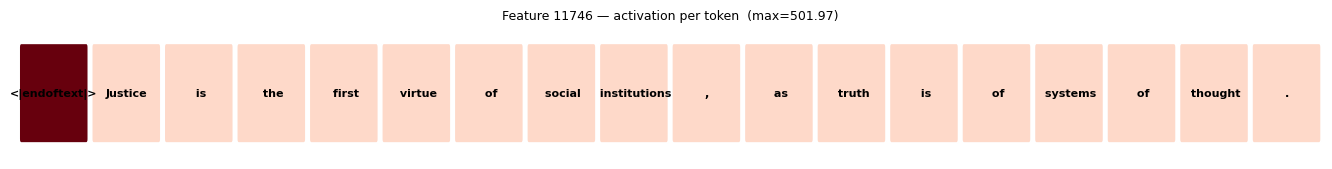

Darker red = stronger activation.
If the feature encodes a concept, the semantically loaded tokens should light up.


In [ ]:
# 🔍 DEMONSTRATION: Token-level heatmap — which words drive the feature?

def plot_token_heatmap(text, feature_idx, model, sae, layer=8):
    token_strs, feature_acts = get_feature_activations(text, model, sae, layer)
    activations = feature_acts[:, feature_idx].cpu().float().numpy()
    max_act     = activations.max()
    if max_act < 1e-8:
        print(f'Feature {feature_idx} does not activate on this text.'); return
    norm_acts = activations / max_act
    fig, ax = plt.subplots(figsize=(max(10, len(token_strs) * 0.75), 1.8))
    ax.set_xlim(0, len(token_strs)); ax.set_ylim(0, 1); ax.axis('off')
    for i, (tok, norm) in enumerate(zip(token_strs, norm_acts)):
        color = plt.cm.Reds(0.15 + 0.85 * float(norm))
        ax.add_patch(mpatches.FancyBboxPatch(
            (i + 0.05, 0.15), 0.9, 0.70, boxstyle='round,pad=0.03',
            facecolor=color, edgecolor='white', lw=1.5))
        ax.text(i + 0.5, 0.5, tok, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'Feature {feature_idx} — activation per token  (max={max_act:.2f})', fontsize=9, pad=6)
    plt.tight_layout(); plt.show()

rawls_quote = 'Justice is the first virtue of social institutions, as truth is of systems of thought.'
top_rawls   = find_top_features(rawls_quote, model, sae, k=3)
print(f'Top feature on Rawls quote: #{top_rawls[0][0]}')
plot_token_heatmap(rawls_quote, top_rawls[0][0], model, sae)
print('Darker red = stronger activation.')
print('If the feature encodes a concept, the semantically loaded tokens should light up.')

## Part 5: Are These Findings Real? Testing for Dataset Artifacts (25 min)

### 📚 The Correlation Problem

Finding that Feature X activates on "justice" text is a **correlation**: the feature and the concept co-occur. But correlations can be spurious.

The specific risk here is called a **dataset artifact**: a feature may appear to encode "justice" only because the test sentences all came from the same corpus — web text (Reddit, Wikipedia, news articles). In that corpus, justice appears overwhelmingly in political commentary, activism, and legal news. The feature might actually encode *that rhetorical register*, not justice as a philosophical concept.

This mirrors a classical problem in **conceptual analysis**: are we capturing the concept itself, or only the culturally specific contexts in which it appears in our evidence base?

### 🧪 The Cross-Register Test

A genuine concept feature should activate **regardless of the stylistic register** in which the concept appears. We test four:

| Register | Hypothesis |
|---------|-----------|
| **Web / informal** | High activation — this is Neuronpedia's home corpus |
| **Academic philosophy** | If truly monosemantic, should still activate |
| **Legal / institutional** | Different genre, same concept |
| **Literary fiction** | Thematic rather than argumentative treatment |

High activation in **only one register** → likely a dataset artifact.  
Consistent activation **across all four** → stronger evidence for genuine concept encoding.

**Important**: Even consistent cross-register activation is still only correlation. It rules out a simple style artifact, but cannot establish that the feature *causes* concept-related behavior. That requires Part 6.

In [ ]:
# Four registers of justice discourse

domain_texts = {
    'Web / informal': [
        'Justice needs to be served — these politicians need to be held accountable for what they did.',
        "There's no justice in this world when rich people can just buy their way out of anything.",
        'We need to fight for justice for all marginalized communities in this country, period.',
    ],
    'Academic philosophy': [
        'Rawlsian justice requires that inequalities benefit the least advantaged members of society.',
        'The concept of distributive justice addresses moral principles governing the fair allocation of goods.',
        'Aristotelian justice as proportional equality differs fundamentally from egalitarian conceptions.',
    ],
    'Legal / institutional': [
        'Procedural justice demands notice and opportunity to be heard before deprivation of rights.',
        'Criminal justice reform advocates argue mandatory minimums undermine proportionate sentencing.',
        'Restorative justice seeks to address harm through cooperative processes rather than punitive ones.',
    ],
    'Literary fiction': [
        'She had always believed in justice, but standing before the judge she wondered if it was just a word.',
        'The old man spoke of justice as if it were a tangible thing you could hold and weigh.',
        'In that village, justice meant whatever the powerful decided it meant on any given day.',
    ],
}
print('Domain texts ready.')

Domain texts ready.


In [ ]:
# Analysis tools — pre-written

def compare_feature_across_domains(feature_idx, domain_texts, model, sae, layer=8):
    results = {}
    for domain_name, texts in domain_texts.items():
        per_text = []
        for text in texts:
            _, feature_acts = get_feature_activations(text, model, sae, layer)
            per_text.append(feature_acts[:, feature_idx].mean().item())
        results[domain_name] = {'mean': float(np.mean(per_text)), 'activations': per_text}
    return results

def plot_domain_comparison(feature_idx, results, concept_label=''):
    domains = list(results.keys())
    means   = [results[d]['mean'] for d in domains]
    colors  = ['#e07b54', '#5b8dd9', '#58b368', '#9b59b6']
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(domains, means, color=colors[:len(domains)], width=0.55, edgecolor='white', lw=1.5)
    ax.set_title(f'Feature {feature_idx}' + (f' ("{concept_label}")' if concept_label else ''), fontsize=10)
    ax.set_ylabel('Average activation'); ax.set_ylim(0, max(means) * 1.4 + 0.005)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=12, ha='right'); plt.tight_layout(); plt.show()
    ratio = max(means) / (min(means) + 1e-8)
    print(f'Activation range: {min(means):.3f} – {max(means):.3f}  (ratio: {ratio:.1f}×)')
    if ratio > 3:
        print('⚠️  HIGH domain sensitivity. Risk of dataset artifact.')
        print('   Activates much more in one register than others.')
        print('   Proceed to Part 6 — causal testing is essential here.')
    else:
        print('✅ Relatively domain-invariant.')
        print('   Consistent activation across registers is a good sign.')
        print('   Still need causal proof in Part 6.')

print('Analysis tools ready.')

Analysis tools ready.


Testing Feature #11746


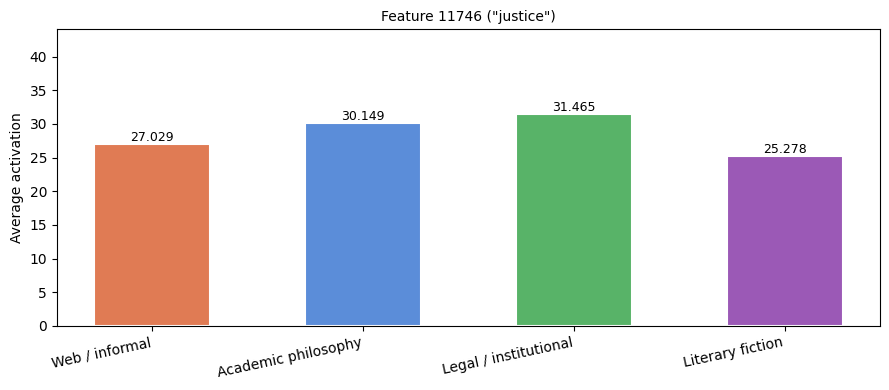

Activation range: 25.278 – 31.465  (ratio: 1.2×)
✅ Relatively domain-invariant.
   Consistent activation across registers is a good sign.
   Still need causal proof in Part 6.


In [ ]:
# 🔍 DEMONSTRATION: Cross-register test for the justice feature

justice_probe = 'Justice requires that we treat all people fairly and equally.'
justice_feat  = find_top_features(justice_probe, model, sae, k=1)[0][0]

print(f'Testing Feature #{justice_feat}')
results_justice = compare_feature_across_domains(justice_feat, domain_texts, model, sae)
plot_domain_comparison(justice_feat, results_justice, concept_label='justice')

### 📖 Interpreting the Cross-Register Result

**If the bars are roughly equal** (ratio < 3×):  
The feature activates on justice text regardless of style. This *rules out* a simple style-based artifact. The feature is likely tracking the concept rather than the rhetorical register.

**If one bar is much higher** (ratio > 3×):  
The feature is sensitive to how justice is *expressed*, not only to the concept itself. The Neuronpedia label may be misleading — it reflects the most common register in the training corpus.

**Either way, correlation alone is not proof**.  
Suppose the feature passes the cross-register test. It is still possible that some *other* variable — academic register, ethical vocabulary, noun-phrase density — is the true cause of activation, and justice is just correlated with it in all four registers. To rule this out, we need to *intervene* on the feature and observe whether the behavior changes. That is Part 6.

In [ ]:
# 🔍 OPTIONAL: Test against the PhilPapers dataset from Lab 02.01
# Real philosophy paper abstracts — the most demanding out-of-distribution test.

philpapers_path = os.path.join(
    '..', '..', 'Lab02.01-Data Fundemantals', 'Data', 'philpapers_enhanced_clean.csv'
)
try:
    phil_df  = pd.read_csv(philpapers_path)
    text_col = next(
        (c for c in ['abstract', 'Abstract', 'text', 'body', 'title']
         if c in phil_df.columns and phil_df[c].notna().sum() > 10),
        phil_df.columns[0]
    )
    mask           = phil_df[text_col].str.contains('justice|fairness|equality', case=False, na=False)
    justice_papers = phil_df[mask][text_col].dropna().tolist()[:3]
    print(f'✅ {len(phil_df)} philosophy papers loaded; {len(justice_papers)} about justice/fairness.')

    if justice_papers:
        phil_results = compare_feature_across_domains(justice_feat,
                           {'PhilPapers abstracts': justice_papers}, model, sae)
        phil_mean    = phil_results['PhilPapers abstracts']['mean']
        web_mean     = results_justice.get('Web / informal', {}).get('mean', 0)
        ratio        = (web_mean + 1e-8) / (phil_mean + 1e-8)
        print(f'  Web/informal:  {web_mean:.3f}')
        print(f'  PhilPapers:    {phil_mean:.3f}  (ratio {ratio:.1f}×)')
        if ratio > 2:
            print('  ⚠️  Lower activation on real philosophy papers — web rhetoric may be driving the feature.')
        else:
            print('  ✅ Similar activation on real philosophy papers — promising.')
except FileNotFoundError:
    print('PhilPapers CSV not found. Upload from Lab02.01-Data Fundemantals/Data/ or mount Drive.')

PhilPapers CSV not found. Upload from Lab02.01-Data Fundemantals/Data/ or mount Drive.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR DOMAIN TEXTS  — swap in four register-varied sentences for your concept.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

your_domain_texts = {    # ← ✏️  replace the sentences inside each register
    'Web / informal': [
        'Being a virtuous person means doing the right thing even when no one is watching.',
        'Virtue signaling is when people act good in public but are selfish in private.',
        'The most virtuous thing you can do is be honest, even when it hurts.',
    ],
    'Academic philosophy': [
        'For Aristotle, virtues are the golden mean between deficiency and excess of character traits.',
        'The unity of the virtues thesis holds that genuine virtue in one domain requires virtue in all.',
        'Virtue epistemology applies the character-based framework to intellectual excellences such as wisdom.',
    ],
    'Legal / institutional': [
        'Civic virtue — the disposition to prioritize the common good — is essential to democratic governance.',
        'Courts have recognized that evidence of a witness virtuous character is admissible in some proceedings.',
        'The virtuous public servant acts in the interest of constituents rather than personal gain.',
    ],
    'Literary fiction': [
        'She had always considered patience her greatest virtue, though today it was failing her.',
        'The old knight believed virtue to be worth more than all the gold in the kingdom.',
        'In the end, his only virtue was his stubbornness — and perhaps that was enough.',
    ],
}

# ──────────────────────────────────── nothing to change below this line ──────

your_feature_idx = your_features[0][0]   # automatically uses the top feature from Part 4

print(f'Testing Feature #{your_feature_idx} for {your_concept.upper()} across four registers')
your_results = compare_feature_across_domains(your_feature_idx, your_domain_texts, model, sae)
plot_domain_comparison(your_feature_idx, your_results, concept_label=your_concept)
print()
print('Record the result: domain-invariant or domain-sensitive?')
print('This informs how strongly to weight your causal test in Part 6.')

## Part 6: Proving Causation — Beyond Correlation (25 min)

### 📚 Why Correlation Is Not Enough

So far we have established:
- Feature X activates when justice text is present (Parts 3–4)
- Feature X activates across different text registers (Part 5)

This rules out simple style artifacts. But it is still consistent with the feature being a **passive detector** — a thermometer that reads the temperature without controlling it. The feature might correlate with justice because the same conditions that produce justice text also produce high feature activation, without the feature *doing* anything.

To establish genuine causal relevance, we need **interventions** — experiments where we change only the feature and observe the effect on behavior. This is precisely the logic of a controlled experiment.

We use two complementary interventions, following James Woodward's **manipulability theory of causation**: a variable is causally relevant to an outcome if manipulating it produces a corresponding change in the outcome.

---

### 🧪 The Three-Part Causal Test

| Test | What we do | What it shows |
|------|-----------|---------------|
| **1. Correlation** | Measure feature activation on concept text | Feature co-occurs with concept (Parts 3–5) |
| **2. Activation (steering)** | *Add* the feature direction to residual stream | Does artificially activating the feature produce concept-related output? |
| **3. Suppression (ablation)** | *Remove* the feature direction from residual stream | Does suppressing the feature reduce concept-related output? |

If tests 2 and 3 both succeed, we have **convergent causal evidence**: the feature promotes the concept when added and suppresses it when removed. This is the same evidential standard used in neuroscience to claim that a brain region "encodes" something.

---

### ⚠️ What Causal Evidence Does Not Establish

Passing all three tests shows the feature is **causally relevant** to the concept. It does not show:
- That the feature is the *only* cause (the concept may also be encoded in other features)
- That we fully *understand* the feature — causal control is a necessary but not sufficient condition for understanding
- That the concept is monosemantically encoded — complex philosophical concepts likely involve *clusters* of features that co-activate

In [ ]:
# Causal intervention functions

def generate_with_steering(prompt, model, sae, feature_idx,
                            strength=20.0, layer=8, max_new_tokens=40):
    '''Test 2 — ACTIVATION: add feature direction to residual stream.'''
    tokens     = model.to_tokens(prompt, prepend_bos=True)
    hook_point = f'blocks.{layer}.hook_resid_pre'
    def steer(value, hook):
        direction = sae.W_dec[feature_idx].to(value.device)
        return value + strength * (direction / (direction.norm() + 1e-8))
    with model.hooks(fwd_hooks=[(hook_point, steer)]):
        with torch.no_grad():
            out = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    return model.tokenizer.decode(out[0])

def generate_with_suppression(prompt, model, sae, feature_idx,
                               layer=8, max_new_tokens=40):
    '''
    Test 3 — SUPPRESSION: project out the feature direction from the residual stream.
    This removes the feature's contribution entirely at every token position.
    If the output becomes less concept-related, the feature was doing causal work.
    '''
    tokens     = model.to_tokens(prompt, prepend_bos=True)
    hook_point = f'blocks.{layer}.hook_resid_pre'
    def suppress(value, hook):
        direction  = sae.W_dec[feature_idx].to(value.device)
        direction  = direction / (direction.norm() + 1e-8)                     # unit vector
        component  = (value * direction).sum(dim=-1, keepdim=True) * direction  # projection
        return value - component                                               # remove it
    with model.hooks(fwd_hooks=[(hook_point, suppress)]):
        with torch.no_grad():
            out = model.generate(tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    return model.tokenizer.decode(out[0])

def causal_test(prompt, model, sae, feature_idx, strength=20.0, layer=8, max_new_tokens=40):
    '''Run all three tests and print a side-by-side comparison.'''
    prompt_tokens = model.to_tokens(prompt, prepend_bos=True)
    with torch.no_grad():
        base_out = model.generate(prompt_tokens, max_new_tokens=max_new_tokens, temperature=0.7, verbose=False)
    baseline   = model.tokenizer.decode(base_out[0])
    activated  = generate_with_steering(prompt, model, sae, feature_idx, strength, layer, max_new_tokens)
    suppressed = generate_with_suppression(prompt, model, sae, feature_idx, layer, max_new_tokens)

    # Decode the prompt tokens to get the exact character offset.
    # (GPT-2's tokenizer adds a leading space before the first token, so len(prompt) alone is off by 1.)
    decoded_prefix = model.tokenizer.decode(prompt_tokens[0])
    suffix = len(decoded_prefix)

    print(f'Prompt:      "{prompt}"')
    print(f'Feature:     #{feature_idx}  (steering strength={strength})')
    print()
    print(f'[BASELINE]   {baseline[suffix:].strip()[:120]}')
    print(f'[ACTIVATED]  {activated[suffix:].strip()[:120]}')
    print(f'[SUPPRESSED] {suppressed[suffix:].strip()[:120]}')
    return baseline, activated, suppressed

print('✅ Causal intervention functions ready.')

In [ ]:
# 🔍 DEMONSTRATION: The three-part causal test on the justice feature

print('=== CAUSAL TEST: JUSTICE FEATURE ===')
print()
baseline, activated, suppressed = causal_test(
    prompt       = 'Philosophy teaches us that',
    model        = model,
    sae          = sae,
    feature_idx  = justice_feat,
    strength     = 20.0,
    max_new_tokens = 40,
)

=== CAUSAL TEST: JUSTICE FEATURE ===

Prompt:      "Philosophy teaches us that"
Feature:     #11746  (steering strength=20.0)

[BASELINE]   aches us that God is the creator of men and women in a more intimate way than many of us would have thought possible. Go
[ACTIVATED]  aches us that knowledge is its own reward. We know that something has been lost in the past and we know that we need to 
[SUPPRESSED] aches us that if at least at least at least at least at least at least at least at least at least at least at least at l


### 📖 Reading the Causal Test Results

**What to look for:**

- **BASELINE → ACTIVATED**: Does the output shift toward the concept when the feature is turned up?  
  If yes: the feature is causally *sufficient* to promote that concept in output.

- **BASELINE → SUPPRESSED**: Does the output shift *away* from the concept when the feature is removed?  
  If yes: the feature is causally *necessary* for that concept to appear in output (or at least a significant contributor).

- **ACTIVATED vs SUPPRESSED**: The contrast between these two should be the largest shift. If the outputs in all three conditions look similar, the feature may not be doing as much causal work as the correlation implied.

**Interpreting weak results**: GPT-2 Small is a small model and its feature geometry is noisier than larger models. Steering and suppression effects may be subtle. A subtle result does not mean the feature is not causal — it means the effect is small relative to other factors in the model. Anthropic's work on Claude 3 Sonnet showed much more dramatic steering effects at scale.

**Try different strengths**: Increase `strength` in the next cell (try 30, 50) to see whether the effect is amplifiable.

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ✏️  YOUR CAUSAL TEST  — adjust the prompt and experiment with strength.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

your_causal_prompt   = 'A philosopher studying character would argue that'   # ← ✏️  try different prompts
your_causal_strength = 20.0   # ← ✏️  experiment: try 10, 30, 50 — higher = stronger effect

# ──────────────────────────────────── nothing to change below this line ──────

your_causal_feature = your_features[0][0]   # automatically uses the top feature from Part 4

print(f'=== CAUSAL TEST: {your_concept.upper()} FEATURE ===')
print()
causal_test(
    prompt      = your_causal_prompt,
    model       = model,
    sae         = sae,
    feature_idx = your_causal_feature,
    strength    = your_causal_strength,
)
print()
print('Interpretation checklist:')
print('  ✓ Does ACTIVATED output contain more of your concept than BASELINE?')
print('  ✓ Does SUPPRESSED output contain less of your concept than BASELINE?')
print('  ✓ If yes to both: convergent causal evidence — the feature causally encodes the concept.')
print('  ✗ If neither: the feature may not be causally central — revisit domain results from Part 5.')

In [ ]:
# 🔍 DEMONSTRATION: Demographic probes — does the model encode different features
# for the same sentence with only the demographic context changed?

probe_pairs = {
    'gender'    : ('She is a talented engineer and scientist.',
                   'He is a talented engineer and scientist.'),
    'sentiment' : ('This argument is wonderful and absolutely excellent.',
                   'This argument is terrible and absolutely awful.'),
    'authority' : ('The judge ruled that the law must be enforced strictly.',
                   'The activist argued that the law must be challenged publicly.'),
}

print('Feature differences across paired sentences (comparing top-20 features each):')
print('=' * 70)
for category, (text_a, text_b) in probe_pairs.items():
    feats_a  = {f for f, _ in find_top_features(text_a, model, sae, k=20)}
    feats_b  = {f for f, _ in find_top_features(text_b, model, sae, k=20)}
    unique_a = sorted(feats_a - feats_b)[:5]
    unique_b = sorted(feats_b - feats_a)[:5]
    print(f'\n{category.upper()}:')
    print(f'  A: "{text_a}"')
    print(f'  B: "{text_b}"')
    print(f'  Features unique to A: {unique_a}')
    print(f'  Features unique to B: {unique_b}')
print()
print('Use neuronpedia_url(feature_idx) or the Part 3 instructions to look up any feature.')
print('Note: these are correlation findings. To know if they matter, you would need causal tests too.')

## Part 7: What This Lab Established — and What It Didn't

### ✅ What We Proved

Through the three-part causal test, you produced **convergent causal evidence** for a feature:

1. **Activation correlation** (Parts 3–5): The feature fires consistently on concept-relevant text across four registers. This rules out a simple style-based artifact.

2. **Causal activation** (Part 6, steering): Adding the feature direction to the residual stream shifts model output toward the concept. The feature is causally *sufficient* to promote the concept.

3. **Causal suppression** (Part 6, ablation): Removing the feature direction shifts output away from the concept. The feature is a significant causal *contributor* to the concept appearing in output.

When all three hold, the standard is equivalent to what neuroscience requires before claiming that a brain region "encodes" a concept: correlation, gain-of-function, and loss-of-function.

---

### ❌ What We Did Not Prove

**Cross-linguistic universality**: We tested only English. A feature that encodes justice *as a concept* — not just justice-in-English — should activate on French translations of Rawls and Chinese legal texts. We did not test this. Language-specific features are likely common in models trained predominantly on English corpora.

**Conceptual precision**: The justice feature may encode "justice *and* closely related concepts" — fairness, rights, equality — rather than justice specifically. Complex philosophical concepts are likely distributed across *clusters* of features that co-activate, not a single monosemantic feature. The individual feature you found may encode one facet of the concept.

**Corpus independence of labels**: Neuronpedia's top-activating examples come from web text. Your interpretation of the feature was shaped by that corpus. A different corpus (PhilPapers, legal case law, translated texts) might suggest a different label. Feature labels are **hypotheses**, not ground truth — they require convergent evidence from multiple annotation sources.

**Full understanding from causal control**: Woodward's manipulability theory of causation holds that causal relevance is established by successful intervention. But causal control is a *necessary*, not *sufficient*, condition for understanding. A surgeon can ablate a brain region without knowing its full computational role. The same applies here.

---

### 📖 Implications for AI Auditing

**SAEs and outcome-based auditing are complementary, not substitutes.**

Labs 03 and 04 measured fairness through *outcomes*: does the model treat demographic groups differently in its predictions? SAEs give us a different instrument: does the model's *internal representation* differ across groups?

These can dissociate:
- A model can have **biased representations** with **fair outcomes** — if representational biases cancel in the final prediction layer.
- A model can have **apparently neutral representations** with **biased outcomes** — if bias is introduced in the final linear transformation, which SAEs do not capture.

Both levels of analysis matter. Representational auditing (SAEs) is sensitive to upstream biases that outcome auditing may miss. Outcome auditing measures what ultimately matters for deployment. Neither alone is sufficient.

**The auditor's constraint**: every feature label is corpus-relative. An audit conducted using only web-text Neuronpedia examples is an audit conducted within a particular cultural and linguistic context. To trust the labels, convergent evidence from multiple corpora — including domain-specific ones like PhilPapers — is required. Otherwise, you may be auditing the corpus, not the model.

## 🎉 Summary

### The Evidence Chain

| Step | What you did | What it established |
|------|-------------|---------------------|
| **Part 3–4** | Found features that activate on concept text | Correlation |
| **Part 5** | Tested activation across four text registers + PhilPapers | Ruled out simple style artifact |
| **Part 6 — Steering** | Added feature direction; measured output shift | Causal sufficiency |
| **Part 6 — Suppression** | Removed feature direction; measured output shift | Causal contribution |
| **All together** | Convergent causal evidence | Feature is causally relevant to concept |

### What an SAE Feature Is (and Isn't)

A feature that passes all tests encodes *a causally relevant direction* in activation space that is associated with a concept. It is not the *only* encoding of that concept, it is not a full explanation of the concept, and its label depends on the corpus used to interpret it.

### The Corpus-Relativity Constraint

Feature labels are hypotheses generated from a specific corpus. Trusting a label requires:
1. Multi-register activation consistency (Part 5)
2. Causal intervention evidence (Part 6)
3. Replication on domain-specific corpora (PhilPapers, translated texts, legal texts)

### Technical Summary

| Skill | What you learned |
|-------|------------------|
| **SAELens** | `SAE.from_pretrained('gpt2-small-res-jb', 'blocks.8.hook_resid_pre')` — 24,576 features |
| **Feature Extraction** | `sae.encode(residuals)` → sparse features; `find_top_features()` ranks them |
| **Cross-Register Test** | `compare_feature_across_domains()` — rules out style artifacts |
| **Steering** | Add `strength × W_dec[feat]` to residual stream — tests causal sufficiency |
| **Suppression** | Project out `W_dec[feat]` direction — tests causal contribution |

---
**Previous Lab:** ← [Lab 08 – Hugging Face Capabilities](../../Lab08-Gentle%20Hugging%20Face-Capabilities%20of%20LLMs/Lab08-lecture-guide.md)  
**Next Lab:** [Lab 10 – Context Engineering (Graph)RAG →](../../Lab10-Context%20Engineering-(Graph)RAGged-LLMs/Lab10-lecture-guide.md)